In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

In [2]:
# Financial parameters as requested
T = 0.25        # Time to maturity (in years)
K = 10.0        # Strike price
r = 0.1         # Risk-free interest rate
sigma = 0.4     # Volatility

# Domain boundaries
S_min = 0.0
S_max = 20.0
t_min = 0.0
t_max = T

In [3]:
def build_model(num_hidden_layers=4, num_neurons=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
    model.add(tf.keras.layers.Dense(1, activation=None)) 
    return model

pinn_N_model = build_model()
pinn_N_model.summary()


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def get_V(model, t, S):
    # The payoff for a call option
    payoff = tf.maximum(S - K, 0.0)
    
    # N(t,S) is the output of the neural network
    N = model(tf.concat([t, S], axis=1))
    
    # A blending function that is zero at t=T and S=0, ensuring boundary conditions hold
    f = (T - t) * S
    
    # The final trial solution. This form strongly satisfies the terminal and boundary conditions.
    V = payoff + f * N
    
    return V

def loss_fn(model, t, S):
    # Use GradientTape to compute derivatives of V
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([t, S])
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch([t, S])
            V = get_V(model, t, S)
        
        V_t = inner_tape.gradient(V, t)
        V_S = inner_tape.gradient(V, S)
    
    V_SS = tape.gradient(V_S, S)
    del tape

    # Black-Scholes PDE residual
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    loss = tf.reduce_mean(tf.square(residual))
    return loss

In [5]:
N_collocation = 20000
t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

In [6]:
epochs = 8000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    """Performs a single training step."""
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col)
    
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

for epoch in range(epochs):
    loss_value = train_step(pinn_N_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

Epoch 500, Loss: 3.3666e-02
Epoch 1000, Loss: 2.5864e-02
Epoch 1500, Loss: 2.3643e-02
Epoch 2000, Loss: 2.1030e-02
Epoch 2500, Loss: 1.7965e-02
Epoch 3000, Loss: 1.5717e-02
Epoch 3500, Loss: 1.4036e-02
Epoch 4000, Loss: 1.3026e-02
Epoch 4500, Loss: 1.2486e-02
Epoch 5000, Loss: 1.2108e-02
Epoch 5500, Loss: 1.4966e-02
Epoch 6000, Loss: 1.1441e-02
Epoch 6500, Loss: 1.1088e-02
Epoch 7000, Loss: 1.0704e-02
Epoch 7500, Loss: 1.0280e-02
Epoch 8000, Loss: 9.8350e-03


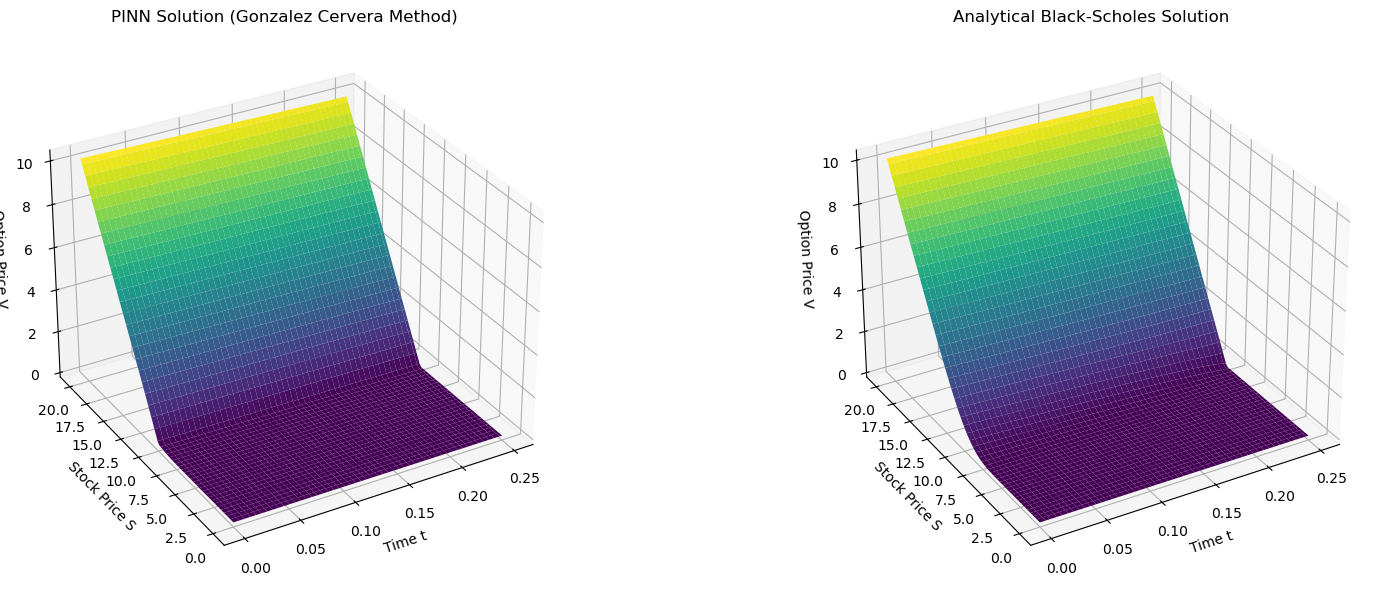

In [7]:
def black_scholes_analytical_call(S, t, K, r, sigma, T):
    """Analytical solution for standard European call option."""
    if t == T:
        return np.maximum(S - K, 0)
    tau = T - t
    if tau <= 1e-8:
        return np.maximum(S - K, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call_price = (S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2))
    return call_price

# Create a grid for plotting
S_plot = np.linspace(S_min, S_max, 100)
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)

# Prepare grid points for prediction, ensuring they are rank-2 tensors
t_flat = tf.reshape(tf.constant(t_grid.flatten(), dtype=DTYPE), (-1, 1))
S_flat = tf.reshape(tf.constant(S_grid.flatten(), dtype=DTYPE), (-1, 1))

# Predict using the trained PINN by constructing the solution V
V_pred_flat = get_V(pinn_N_model, t_flat, S_flat)
V_pred = tf.reshape(V_pred_flat, S_grid.shape).numpy()

# Calculate analytical solution
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        s_val = S_grid[i, j] if S_grid[i, j] > 1e-8 else 1e-8
        V_analytical[i, j] = black_scholes_analytical_call(s_val, t_grid[i, j], K, r, sigma, T)

# Plotting
fig = plt.figure(figsize=(18, 6))

# PINN Solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis')
ax1.set_title('PINN Solution (Gonzalez Cervera Method)')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, -120)

# Analytical Solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis')
ax2.set_title('Analytical Black-Scholes Solution')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, -120)

plt.tight_layout()
plt.show()

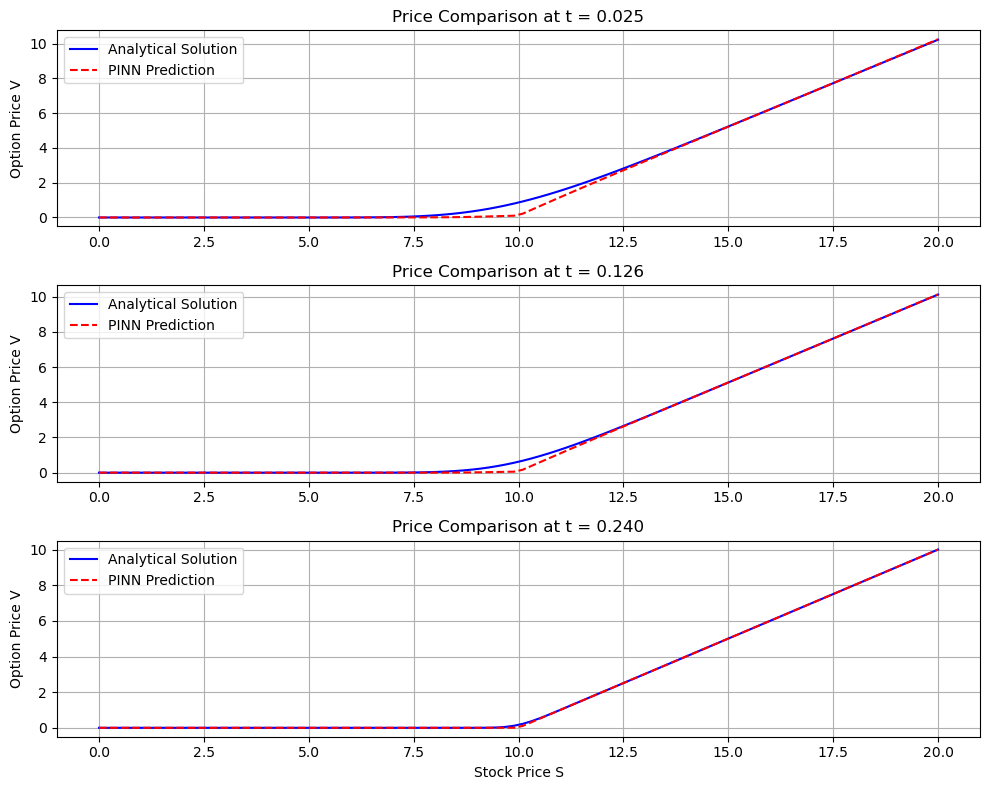

In [8]:
plt.figure(figsize=(10, 8))
time_slices_indices = [10, 50, 95]
time_slices_values = [t_plot[i] for i in time_slices_indices]

# Create a subplot for each time slice
for i, time_idx in enumerate(time_slices_indices):
    plt.subplot(len(time_slices_indices), 1, i+1)
    
    # Plot analytical solution as a solid blue line
    plt.plot(S_plot, V_analytical[time_idx, :], 'b-', label='Analytical Solution')
    
    # Plot PINN prediction as a dashed red line
    plt.plot(S_plot, V_pred[time_idx, :], 'r--', label='PINN Prediction')
    
    plt.ylabel('Option Price V')
    plt.title(f'Price Comparison at t = {time_slices_values[i]:.3f}')
    plt.grid(True)
    plt.legend()

plt.xlabel('Stock Price S')
plt.tight_layout()
plt.show()

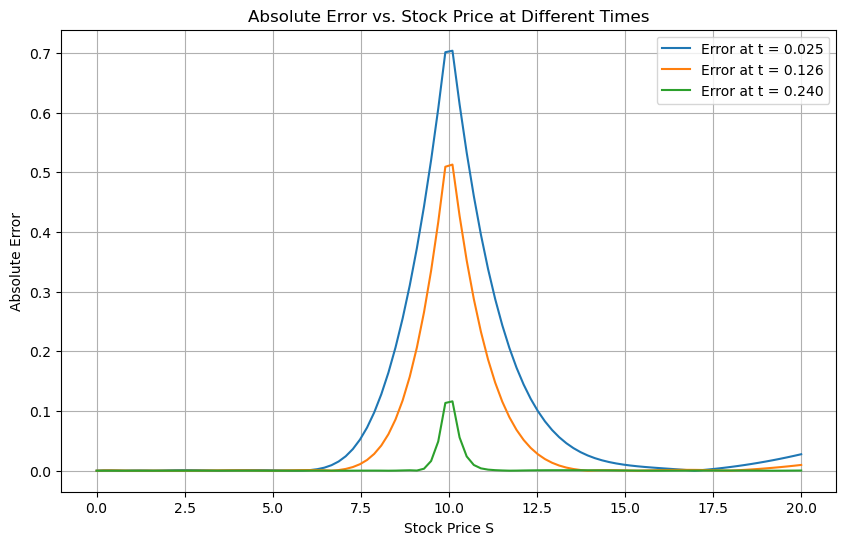

In [9]:
plt.figure(figsize=(10, 6))

# Plot the error curve for each time slice
for i, time_idx in enumerate(time_slices_indices):
    error = np.abs(V_pred[time_idx, :] - V_analytical[time_idx, :])
    plt.plot(S_plot, error, label=f'Error at t = {time_slices_values[i]:.3f}')

plt.title('Absolute Error vs. Stock Price at Different Times')
plt.xlabel('Stock Price S')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# ======= EU Market Underlying Data: Analytical Black-Scholes vs Your PINNs Model =======

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 5 European markets
eu_underlyings = {
    "EU Index (EURO STOXX 50)": "^STOXX50E",
    "Germany (DAX)": "^GDAXI",
    "France (CAC 40)": "^FCHI",
    "UK (FTSE 100)": "^FTSE",
    "Netherlands (AEX)": "^AEX"
}

# Use contract parameters already defined in your notebook
K_val = K
T_val = T
r_val = r
sigma_val = sigma

rows = []

for market, ticker in eu_underlyings.items():
    print(f"\n🔹 Market: {market}")

    df = yf.download(ticker, period="1y", interval="1d")
    df.dropna(inplace=True)

    # Extract Close price properly
    if isinstance(df.columns, pd.MultiIndex):
        S_values = df["Close"].iloc[:, 0].values
    else:
        S_values = df["Close"].values

    # Generate time values from your domain
    t_values = np.linspace(t_min, t_max, len(S_values))

    # Compute analytical Black-Scholes price for each (S,t)
    analytical_prices = np.array([
        black_scholes_call(S, K_val, T_val - t, r_val, sigma_val) for S, t in zip(S_values, t_values)
    ])

    # Build model input exactly matching your PINNs training input (S, t, r, sigma)
    pinn_input = np.column_stack([
        S_values,
        t_values,
        np.full(len(S_values), r_val),
        np.full(len(S_values), sigma_val)
    ])

    # Run inference using your actual trained model
    pinn_prices = model.predict(pinn_input).flatten()

    # Metrics
    rmse = sqrt(mean_squared_error(analytical_prices, pinn_prices))
    mae = mean_absolute_error(analytical_prices, pinn_prices)

    rows.append({"Market": market, "MAE": mae, "RMSE": rmse})

    # Plot comparison
    plt.figure()
    plt.plot(analytical_prices, label="Analytical Black-Scholes")
    plt.plot(pinn_prices, label="Your PINNs Model")
    plt.title(f"{market} — Analytical vs PINNs")
    plt.legend()
    plt.show()

# Summary
print("\n==================== SUMMARY ====================")
print(pd.DataFrame(rows))



🔹 Market: EU Index (EURO STOXX 50)


C:\Users\user\AppData\Local\Temp\ipykernel_12264\1228853076.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed


NameError: name 'black_scholes_call' is not defined